In [25]:
import psycopg2
from dotenv import load_dotenv
import os 

load_dotenv()
url = os.getenv("DATABASE_URL")

In [26]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

In [27]:
cur.execute(
    """
    SELECT DISTINCT ticker
    FROM orderbooks
    """
)
tickers = [row[0] for row in cur.fetchall()]
print(tickers)

['SR320CC6', 'SR320CD6A', 'SR320CO6D', 'SR310CD6', 'SR300CD6A', 'SR310CC6D', 'SR300CP6', 'SR320CP6A', 'SR320CD6', 'SR300CO6D', 'SR320CP6', 'SR320CC6D', 'SR310CP6', 'SR300CD6', 'SR310CO6D', 'SR310CP6A', 'SR310CC6', 'SR300CC6D', 'SR300CP6A', 'SR300CC6', 'SR310CD6A']


In [50]:
import pandas as pd

ticker = "SR320CC6"
columns = ["id", "ticker", "timestamp", "bids", "asks"] 

query = f"""
SELECT {', '.join(columns)}
FROM orderbooks
WHERE ticker = '{ticker}'
"""

option_df = pd.read_sql_query(query, conn)

option_df['timestamp'] = pd.to_datetime(option_df['timestamp'])
option_df.set_index('timestamp', inplace=True)

option_df['best_bid'] = option_df['bids'].apply(lambda bids: bids[0]['price'] if bids else None)
option_df['best_ask'] = option_df['asks'].apply(lambda asks: asks[0]['price'] if asks else None)
option_df['mid_price'] = option_df['best_bid'] + (option_df['best_ask'] - option_df['best_bid'])/2
option_df['spread'] = option_df['best_ask'] - option_df['best_bid']

option_df.drop(columns=['bids', 'asks', 'id'], inplace=True)
option_df = option_df[~option_df.index.duplicated(keep='first')]
option_df.drop_duplicates(inplace=True)
option_df.head()

C:\Users\bakae\AppData\Local\Temp\ipykernel_4688\92435234.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  option_df = pd.read_sql_query(query, conn)


,ticker,best_bid,best_ask,mid_price,spread
timestamp,,,,,
2026-03-11 16:44:09+00:00,SR320CC6,1.11,1.50,1.305,0.39
2026-03-12 07:27:03+00:00,SR320CC6,0.70,1.46,1.080,0.76
2026-03-12 07:27:06+00:00,SR320CC6,0.93,1.46,1.195,0.53
2026-03-11 16:50:00+00:00,SR320CC6,1.11,1.49,1.300,0.38
2026-03-11 17:12:59+00:00,SR320CC6,1.30,1.49,1.395,0.19


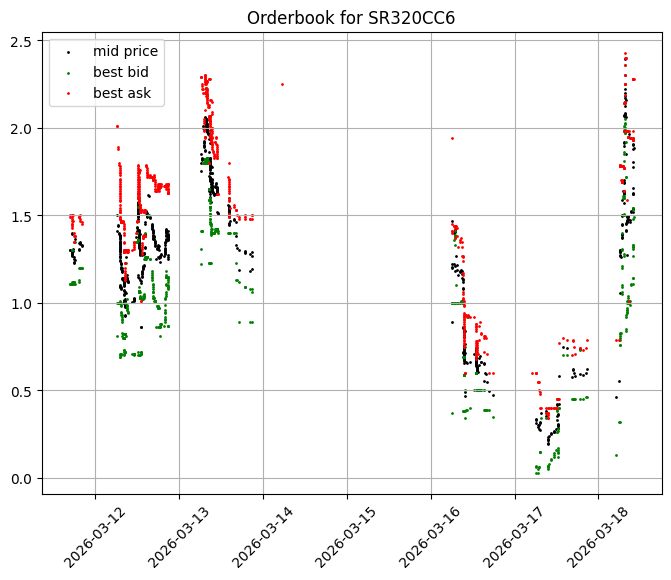

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(option_df.index, option_df['mid_price'], color="black", s=1, label="mid price")
plt.scatter(option_df.index, option_df['best_bid'], color="green", s=1, label="best bid")
plt.scatter(option_df.index, option_df['best_ask'], color="red", s=1, label="best ask")
plt.title(f"Orderbook for {ticker}")
plt.tick_params(axis='x', rotation=45)
plt.legend()
plt.grid()
plt.show()

In [52]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src.bks_api_func import authorize, get_candles

In [65]:
token = os.getenv("BKS_TOKEN")
access_token = authorize(token)

earliest_timestamp = df.index[0].strftime("%Y-%m-%d %H:%M:%S")
latest_timestamp = df.index[-1].strftime("%Y-%m-%d %H:%M:%S")

stock_candles = get_candles(access_token, "SBER", earliest_timestamp, latest_timestamp, "TQBR", "H1")
stock_df = pd.DataFrame(stock_candles)
stock_df['time'] = pd.to_datetime(stock_df['time'])
stock_df = stock_df.set_index('time')
stock_df.head(5)

,open,close,high,low,volume
time,,,,,
2026-03-18 06:00:00+00:00,321.12,320.74,321.50,320.28,9.523296e+08
2026-03-18 05:00:00+00:00,319.80,321.13,321.94,319.79,1.358185e+09
2026-03-18 04:00:00+00:00,319.79,319.80,319.90,318.80,2.991710e+08
2026-03-18 03:00:00+00:00,319.80,319.80,319.80,319.80,5.689562e+06
2026-03-17 20:00:00+00:00,319.06,319.69,319.73,319.06,5.415553e+08


In [68]:
from src.black_scholes import solve_black_scholes
from datetime import datetime

strike_price = 320 
vol = 0.2
rf = 0.15
option_maturity_date = "2026-03-18 00:00:00"
option_maturity_date = datetime.strptime(option_maturity_date, "%Y-%m-%d %H:%M:%S")

stock_df['bs_price'] = None
for index in stock_df.index:
    price = stock_df['close'][index]
    
    fair_price = solve_black_scholes(price, strike_price, rf, vol, option_maturity_date, index, option_type="call")['price']
    stock_df.loc[index, 'bs_price'] = fair_price
stock_df.head(5)

,open,close,high,low,volume,bs_price
time,,,,,,
2026-03-18 06:00:00+00:00,321.12,320.74,321.50,320.28,9.523296e+08,0.0
2026-03-18 05:00:00+00:00,319.80,321.13,321.94,319.79,1.358185e+09,0.0
2026-03-18 04:00:00+00:00,319.79,319.80,319.90,318.80,2.991710e+08,0.0
2026-03-18 03:00:00+00:00,319.80,319.80,319.80,319.80,5.689562e+06,0.0
2026-03-17 20:00:00+00:00,319.06,319.69,319.73,319.06,5.415553e+08,1.247642


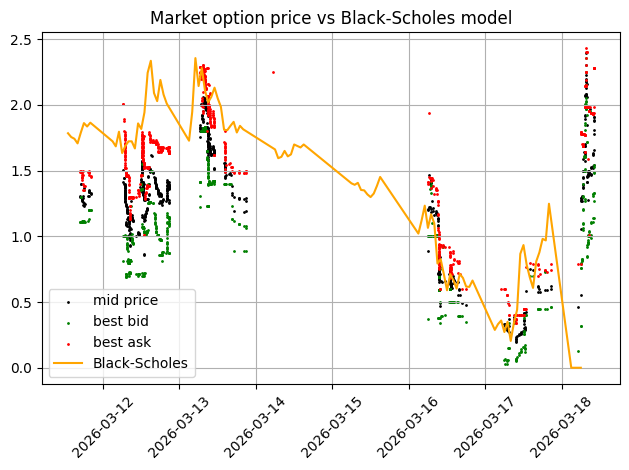

In [72]:
plt.scatter(option_df.index, option_df['mid_price'], color="black", s=1, label="mid price")
plt.scatter(option_df.index, option_df['best_bid'], color="green", s=1, label="best bid")
plt.scatter(option_df.index, option_df['best_ask'], color="red", s=1, label="best ask")

plt.plot(stock_df.index, stock_df['bs_price'], label="Black-Scholes", color="orange")

plt.tick_params(axis='x', rotation=45)
plt.grid()
plt.legend()
plt.title("Market option price vs Black-Scholes model")
plt.tight_layout()
plt.show()